In [37]:
import dac
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import torch

import utils
import dacsound
import json
import os

from audiotools import AudioSignal
from IPython.display import Audio, display, Javascript, HTML

In [38]:

sr = 44100
device = torch.device('cpu') # or 'cuda'
GENERATE_LATENTS = False

model_path = dac.utils.download(model_type="44khz")
model = dac.DAC.load(model_path)
model.to(device);
model.eval();

/home/inspektral/miniconda3/envs/dacformer/lib/python3.10/site-packages/torch/nn/utils/weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


In [39]:
dac_silence = dacsound.DACSound(model, utils.silence(1, sr), sr)
dac_sine = dacsound.DACSound(model, utils.sine(1000, 1, sr), sr)
dac_noise = dacsound.DACSound(model, utils.noise(1, sr), sr)

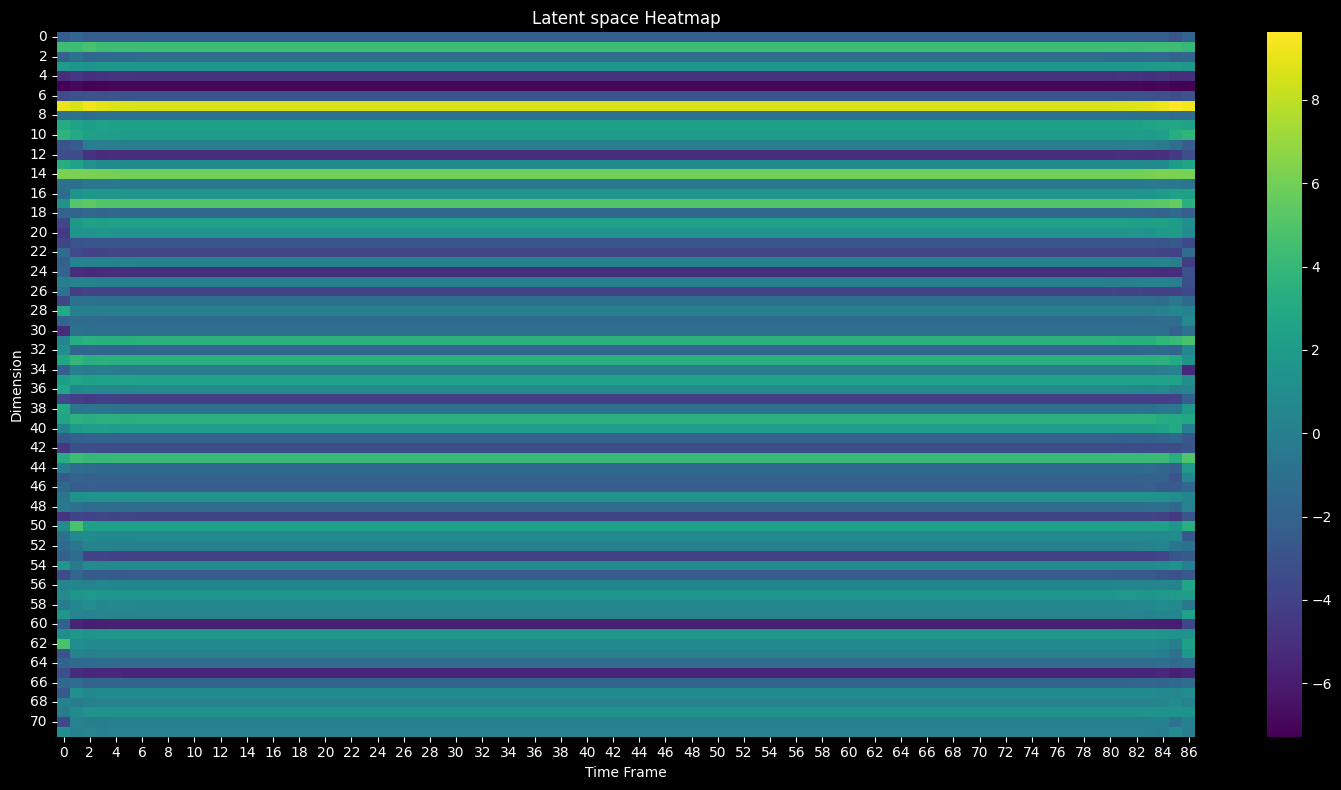

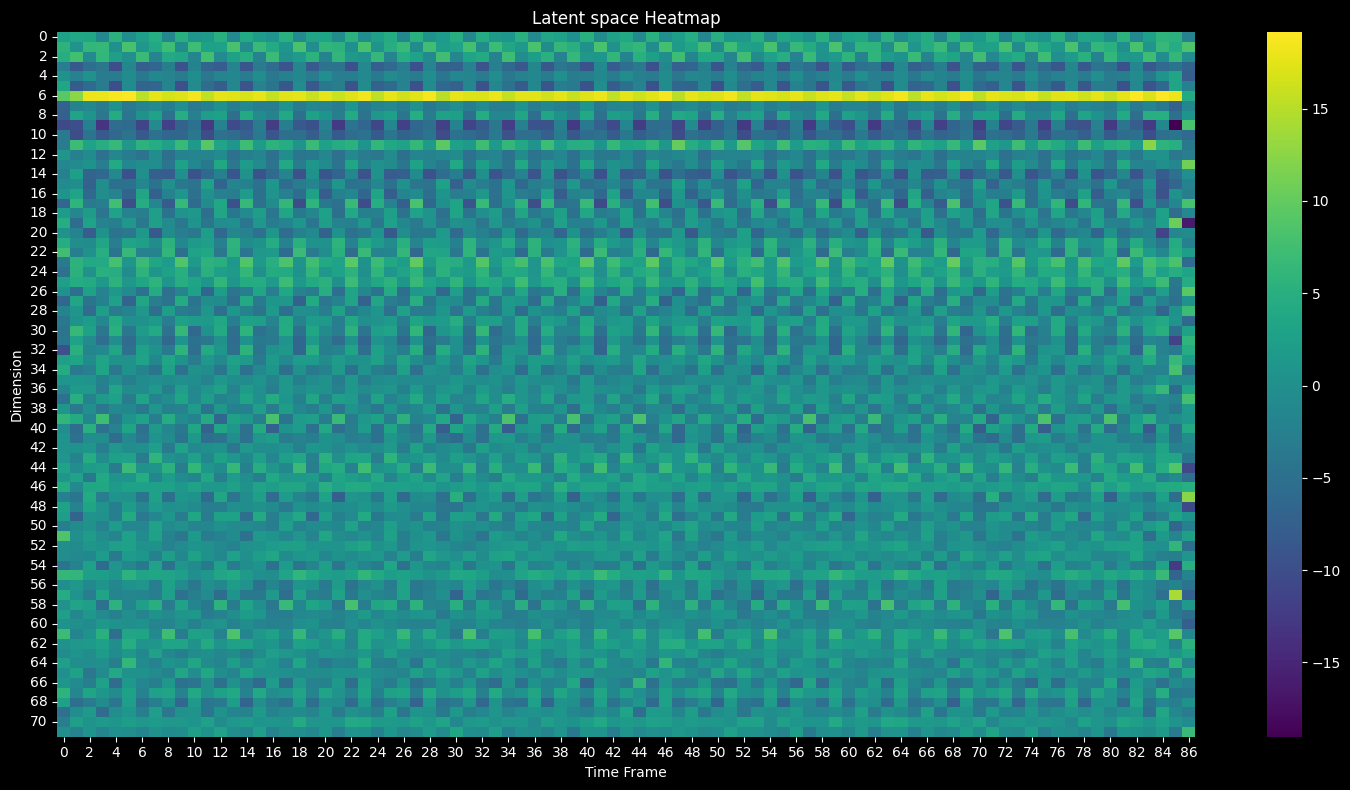

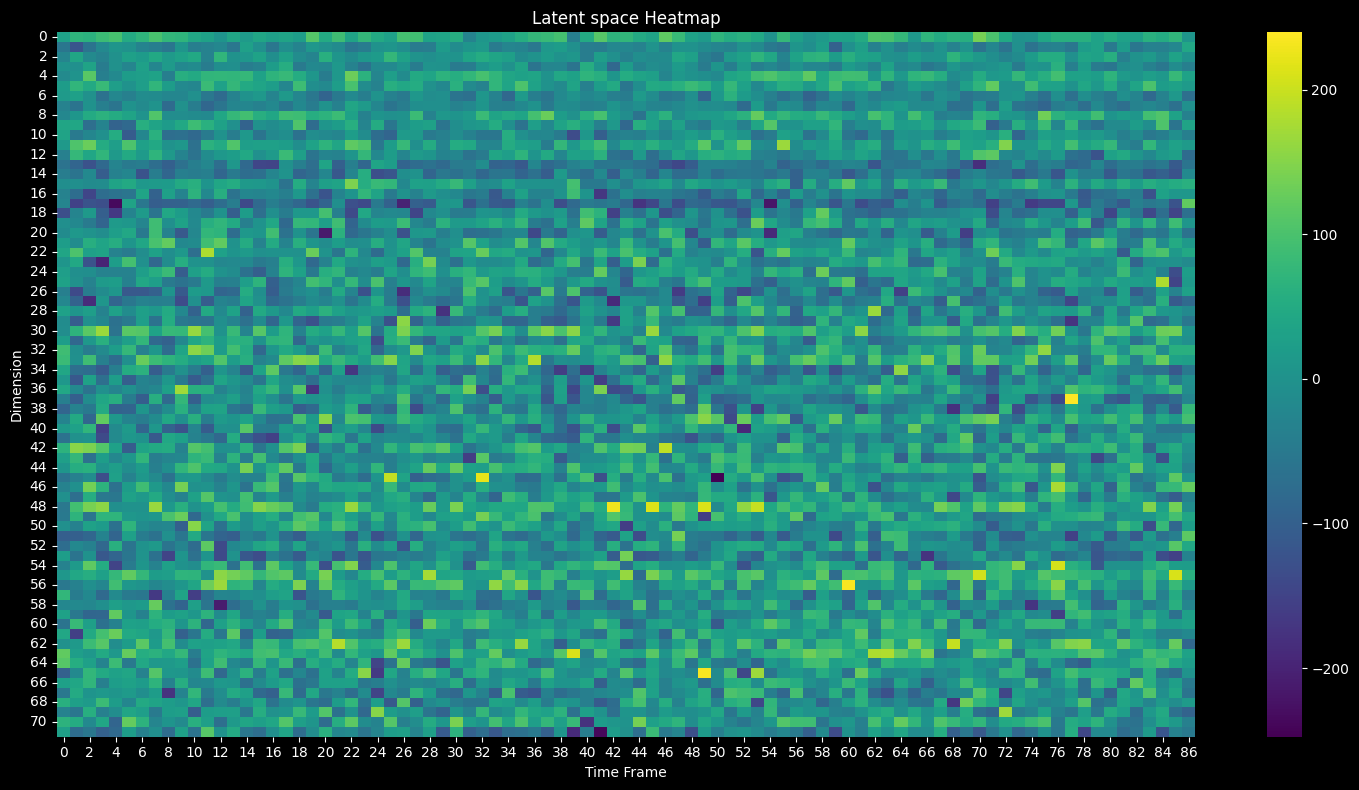

In [40]:
utils.plot_heatmap(dac_silence.latents)
utils.plot_heatmap(dac_sine.latents)
utils.plot_heatmap(dac_noise.latents)

# Are sines of different frequencies the same distance from silence?

In [41]:
if GENERATE_LATENTS:

    latents = {}
    avg_latents = []
    rms_latents = []
    freqs = np.logspace(np.log10(50), np.log10(10000), 400)

    for f in freqs:
        dac_sine = dacsound.DACSound(model, utils.sine(f, 1, sr), sr)
        latents[f] = dac_sine.latents
        avg = torch.mean(dac_sine.latents, dim=2)
        avg_latents.append(avg)
        rms = torch.sqrt(torch.mean(dac_sine.latents**2, dim=2))
        rms_latents.append(rms)

    # Save latents

    JSON_PATH = "./data/latents_freqs.json"
    latents = {k: v.cpu().detach().numpy().tolist() for k, v in latents.items()}
    json.dump(latents, open(JSON_PATH, "w"))

In [42]:
# Load latents
latents_sine = json.load(open("./data/latents_freqs.json"))

latents = {}
freqs = []
avg_latents = []
rms_latents = []

for f, l in latents_sine.items():
    latents[float(f)] = torch.tensor(l)
    freqs.append(float(f))
    avg_latents.append(torch.mean(torch.tensor(l), dim=2))
    rms_latents.append(torch.sqrt(torch.mean(torch.tensor(l)**2, dim=2)))


In [43]:
avg_silence = torch.mean(dac_silence.latents, dim=2).cpu().detach().numpy().flatten()

distances = []
for avg in avg_latents:
    distances.append(np.linalg.norm(avg_silence - avg.cpu().detach().numpy().flatten()))

distance_average = np.mean(distances)
distance_std = np.std(distances)

Average distance: 32.87, std: 6.25
Average distance (RMS):  23.11, std:  4.68


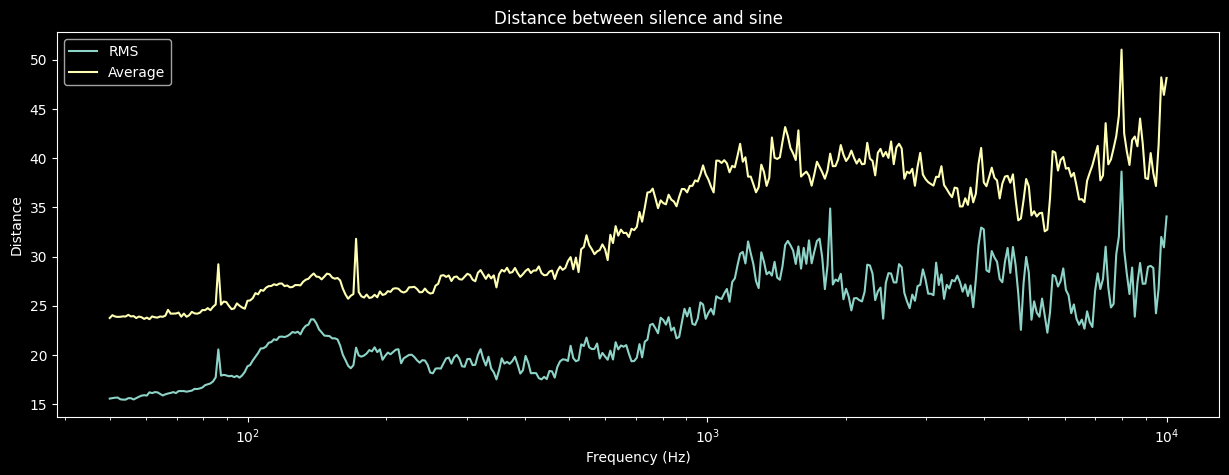

In [44]:
rms_silence = torch.sqrt(torch.mean(dac_silence.latents**2, dim=2)).cpu().detach().numpy().flatten()

distances_rms = []
for rms in rms_latents:
    distances_rms.append(np.linalg.norm(rms_silence - rms.cpu().detach().numpy().flatten()))

distance_rms_average = np.mean(distances_rms)
distance_rms_std = np.std(distances_rms)

print(f"Average distance: {distance_average:.2f}, std: {distance_std:.2f}")
print(f"Average distance (RMS): {distance_rms_average: .2f}, std: {distance_rms_std: .2f}")

plt.figure(figsize=(15, 5))
plt.plot(freqs, distances_rms, label='RMS')
plt.plot(freqs, distances, label='Average')
plt.xscale('log')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Distance')
plt.title('Distance between silence and sine')
plt.legend()
plt.show()

# What about amplitude?

In [45]:
if GENERATE_LATENTS:

    latents_sine = {}
    avg_latents_sine = []
    rms_latents_sine = []

    latents_noise = {}
    avg_latents_noise = []
    rms_latents_noise = []

    db_range = np.linspace(-96, 0, 400)
    amps = np.power(10, db_range/20)

    for a in amps:
        dac_sine = dacsound.DACSound(model, utils.sine(1000, 1, sr)*a, sr)
        latents_sine[a] = dac_sine.latents

        dac_noise = dacsound.DACSound(model, utils.noise(1, sr)*a, sr)
        latents_noise[a] = dac_noise.latents

    JSON_PATH = "./data/latents_amps_sine.json"
    latents = {k: v.cpu().detach().numpy().tolist() for k, v in latents_sine.items()}
    json.dump(latents, open(JSON_PATH, "w"))

    JSON_PATH = "./data/latents_amps_noise.json"
    latents = {k: v.cpu().detach().numpy().tolist() for k, v in latents_noise.items()}
    json.dump(latents, open(JSON_PATH, "w"))

    GENERATE_LATENTS = False

In [46]:
# load latents
latents_sine = json.load(open("./data/latents_amps_sine.json"))
latents_noise = json.load(open("./data/latents_amps_noise.json"))

amps = []
db_range = []

avg_latents_sine = []
rms_latents_sine = []
avg_latents_noise = []
rms_latents_noise = []

for k, v in latents_sine.items():
    amps.append(float(k))
    db_range.append(20*np.log10(float(k)))
    
    latents_sine[k] = torch.tensor(v)
    avg = torch.mean(latents_sine[k], dim=2)
    avg_latents_sine.append(avg)
    rms = torch.sqrt(torch.mean(latents_sine[k]**2, dim=2))
    rms_latents_sine.append(rms)

for k, v in latents_noise.items():
    latents_noise[k] = torch.tensor(v)
    avg = torch.mean(latents_noise[k], dim=2)
    avg_latents_noise.append(avg)
    rms = torch.sqrt(torch.mean(latents_noise[k]**2, dim=2))
    rms_latents_noise.append(rms)

In [47]:
distances_sine = []
for avg in avg_latents_sine:
    distances_sine.append(np.linalg.norm(avg_silence - avg.cpu().detach().numpy().flatten()))

distance_average = np.mean(distances_sine)
distance_std = np.std(distances_sine)


In [48]:
distances_noise = []
for avg in avg_latents_noise:
    distances_noise.append(np.linalg.norm(avg_silence - avg.cpu().detach().numpy().flatten()))

distance_average_noise = np.mean(distances_noise)
distance_std_noise = np.std(distances_noise)

Average distance: 24.82, std: 5.47
Average distance (RMS):  23.11, std:  4.68


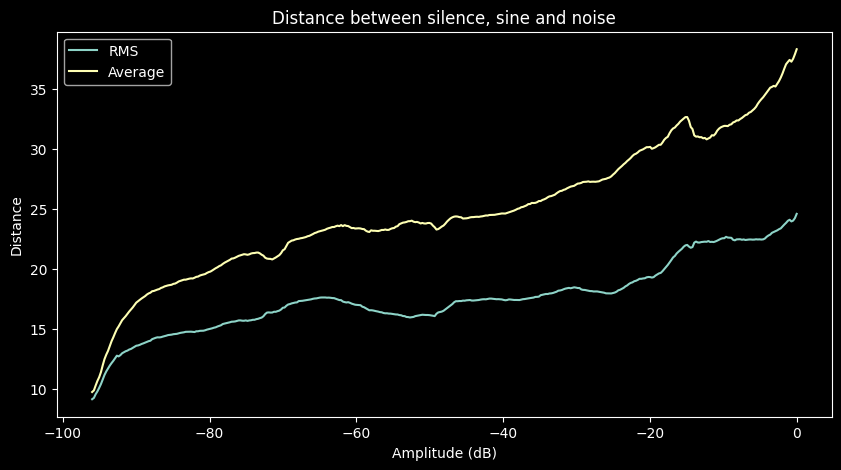

In [49]:
distances_rms_sine = []
for rms in rms_latents_sine:
    distances_rms_sine.append(np.linalg.norm(rms_silence - rms.cpu().detach().numpy().flatten()))

distance_rms_average = np.mean(distances_rms)
distance_rms_std = np.std(distances_rms)

distances_rms_noise = []
for rms in rms_latents_noise:
    distances_rms_noise.append(np.linalg.norm(rms_silence - rms.cpu().detach().numpy().flatten()))

distance_rms_average_noise = np.mean(distances_rms_noise)
distance_rms_std_noise = np.std(distances_rms_noise)

print(f"Average distance: {distance_average:.2f}, std: {distance_std:.2f}")
print(f"Average distance (RMS): {distance_rms_average: .2f}, std: {distance_rms_std: .2f}")

plt.figure(figsize=(10, 5))
plt.plot(db_range, distances_rms_sine, label='RMS')
plt.plot(db_range, distances_sine, label='Average')
# plt.plot(db_range, distances_rms_noise, label='RMS Noise')
# plt.plot(db_range, distances_noise, label='Average Noise')
plt.xlabel('Amplitude (dB)')
plt.ylabel('Distance')
plt.title('Distance between silence, sine and noise')
plt.legend()
plt.show()

Well that didn't taught us much

# Okay lets try some creative decoding now

torch.Size([1, 72, 862])


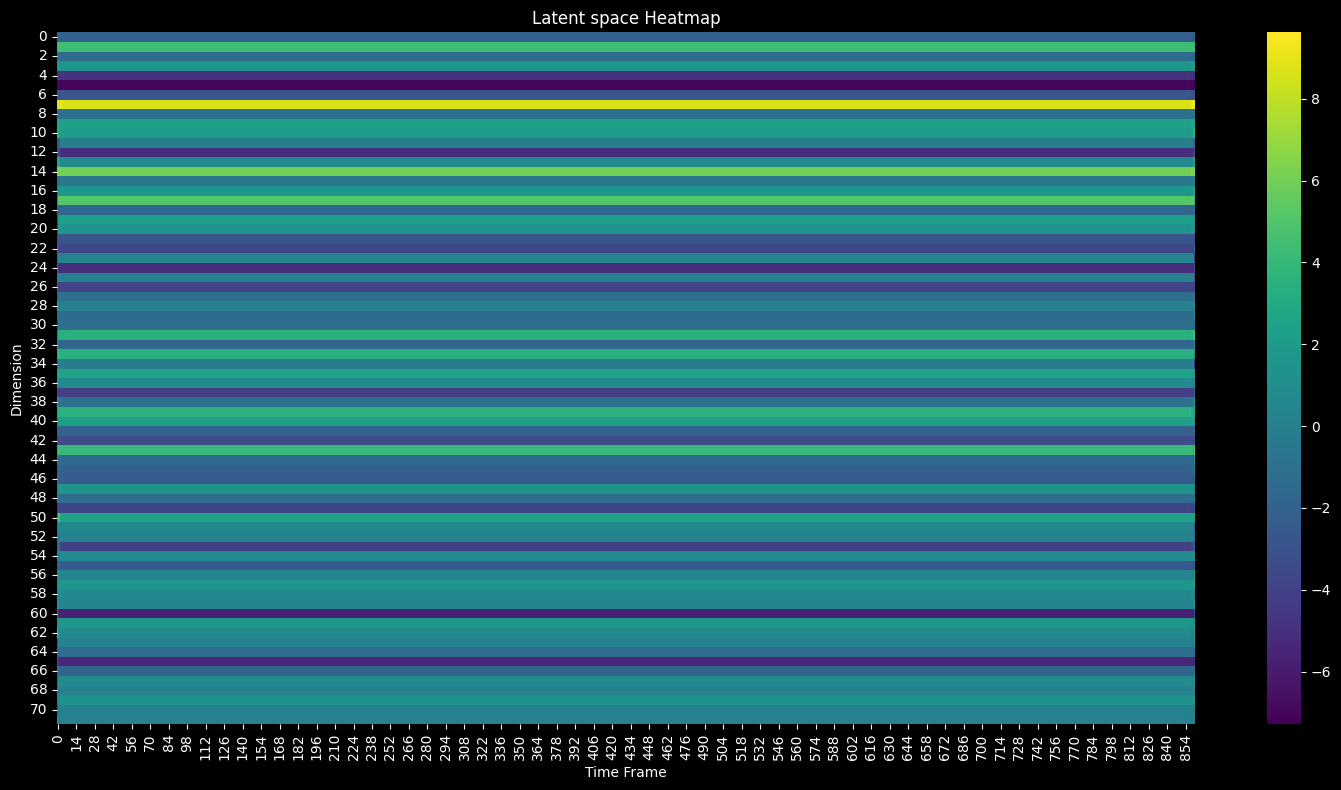

In [63]:
dac_silence = dacsound.DACSound(model, utils.silence(10, sr), sr)

print(dac_silence.latents.shape)

utils.plot_heatmap(dac_silence.latents)

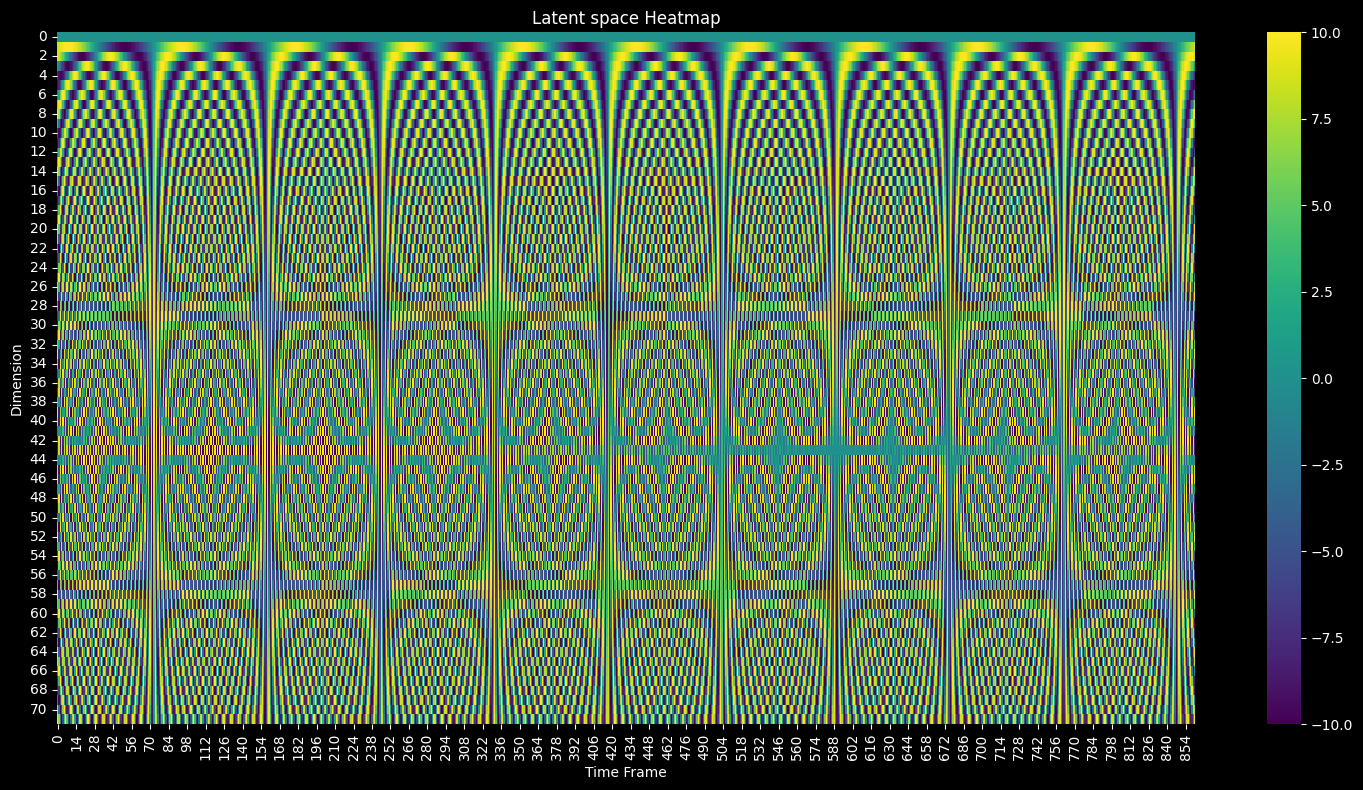

In [ ]:

sine = np.sin(2*np.pi*10*np.linspace(0, 1, len(dac_silence.latents[0,0,:])))*10

for i in range(dac_silence.latents.shape[1]):
    sine = 10*np.sin(i+2*np.pi*10*i*np.linspace(0, 1, len(dac_silence.latents[0,0,:])))*10
    dac_silence.latents[0,i,:] = torch.tensor(sine)

utils.plot_heatmap(dac_silence.latents)

audio = dac_silence.decode_from_latents()
display(Audio(audio, rate=sr))

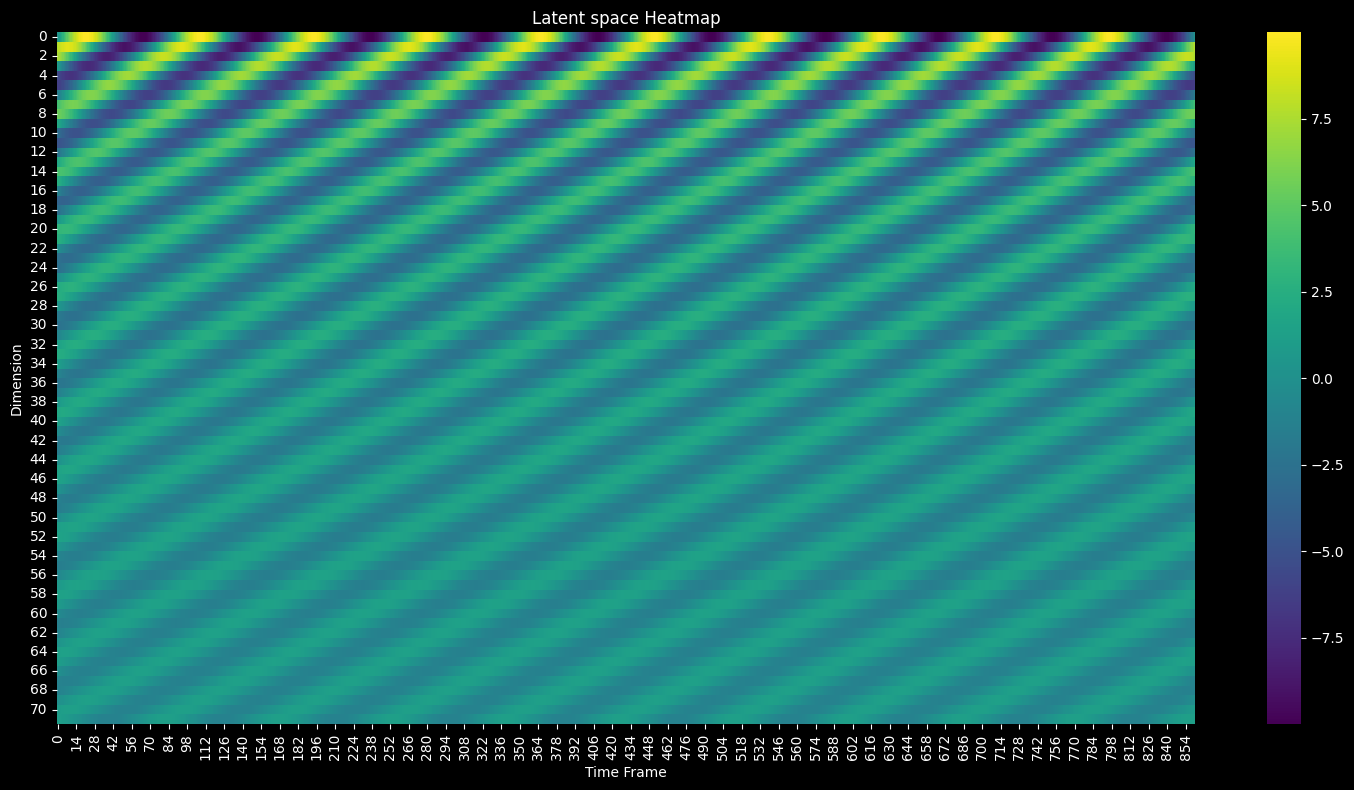

In [ ]:

sine = np.sin(2*np.pi*10*np.linspace(0, 1, len(dac_silence.latents[0,0,:])))*10

for i in range(dac_silence.latents.shape[1]):
    sine = np.sin(i+2*np.pi*10*np.linspace(0, 1, len(dac_silence.latents[0,0,:])))*10
    dac_silence.latents[0,i,:] = torch.tensor(sine)

utils.plot_heatmap(dac_silence.latents)

audio = dac_silence.decode_from_latents()
display(Audio(audio, rate=sr))

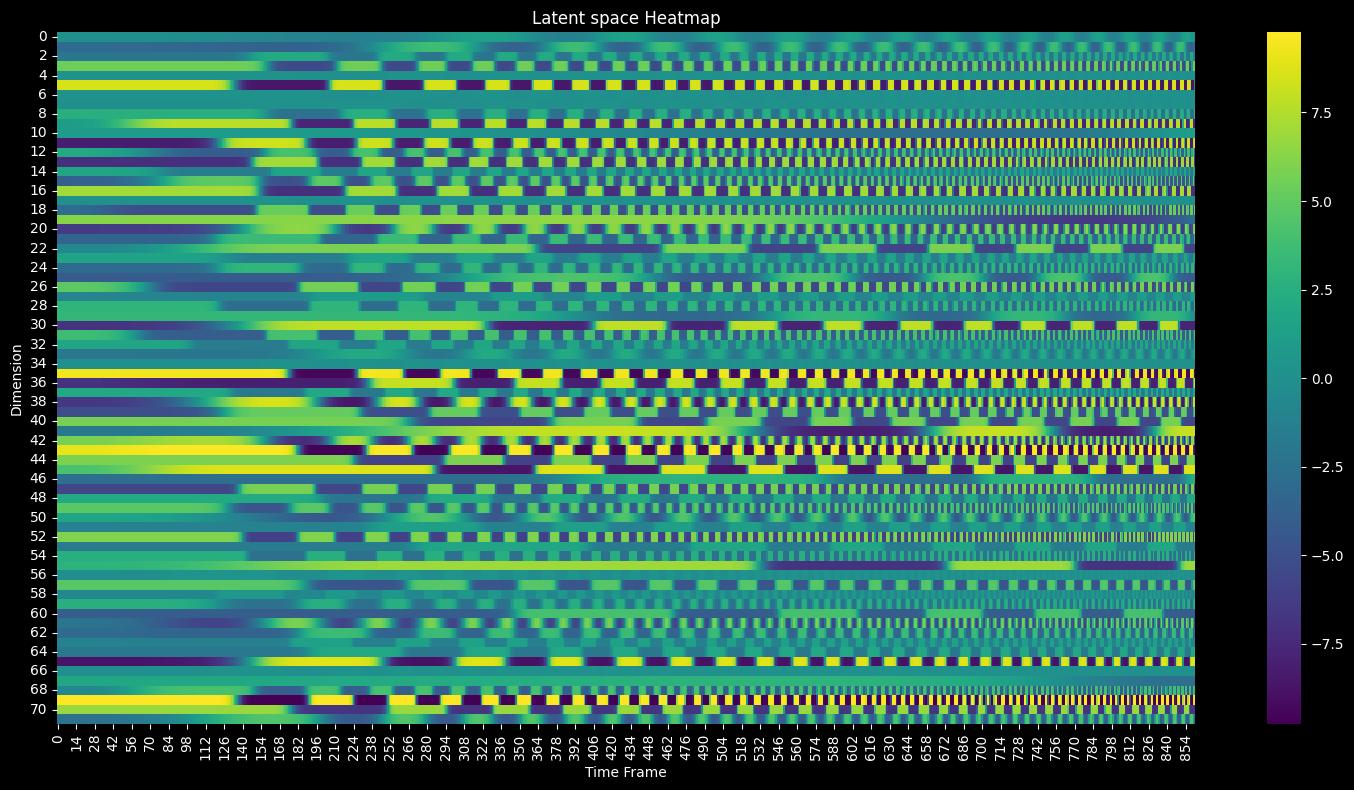

In [96]:
import random
sine = np.sin(2*np.pi*10*np.linspace(0, 1, len(dac_silence.latents[0,0,:])))*10

for i in range(dac_silence.latents.shape[1]):
    sine = np.tanh(random.random()*10*np.sin(i*random.random()+2*np.pi*100*random.random()*np.linspace(0, 1, len(dac_silence.latents[0,0,:]))**3))*(10*(random.random()*2-1))
    dac_silence.latents[0,i,:] = torch.tensor(sine)

utils.plot_heatmap(dac_silence.latents)

audio = dac_silence.decode_from_latents()
display(Audio(audio, rate=sr))

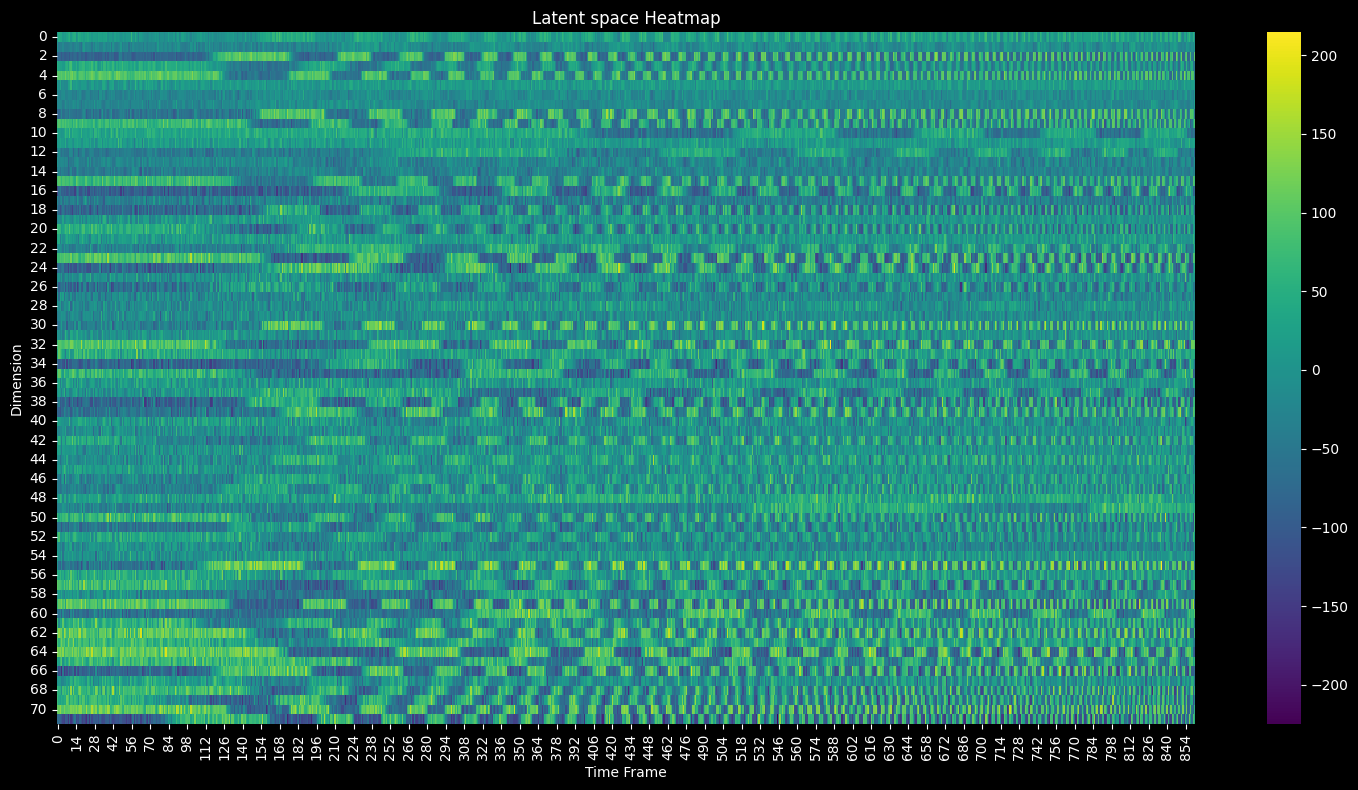

In [101]:
import random
sine = np.sin(2*np.pi*10*np.linspace(0, 1, len(dac_silence.latents[0,0,:])))*10

dac_noise = dacsound.DACSound(model, utils.noise(10, sr), sr)

for i in range(dac_silence.latents.shape[1]):
    sine = 10*np.tanh(random.random()*10*np.sin(i*random.random()+2*np.pi*100*random.random()*np.linspace(0, 1, len(dac_silence.latents[0,0,:]))**3))*(10*(random.random()*2-1))
    dac_silence.latents[0,i,:] = torch.tensor(sine)+dac_noise.latents[0,i,:]*0.5

utils.plot_heatmap(dac_silence.latents)

audio = dac_silence.decode_from_latents()
display(Audio(audio, rate=sr))